In [1]:
from astropy.io import fits
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from collections import Counter

In [2]:
hdulist = fits.open('../../data/allStarLite-dr17-synspec_rev1.fits')
hdu1_data = hdulist[1].data
df4 = pd.DataFrame(hdu1_data.tolist(), columns=hdu1_data.names)



In [3]:
df = df4

In [36]:
df = df.drop_duplicates(subset='APOGEE_ID')
df = df.iloc[1:]

In [37]:
df.head()

,APOGEE_ID,TELESCOPE,FIELD,ALT_ID,RA,DEC,GLON,GLAT,J,J_ERR,...,NI_FE_ERR,NI_FE_FLAG,CU_FE,CU_FE_SPEC,CU_FE_ERR,CU_FE_FLAG,CE_FE,CE_FE_SPEC,CE_FE_ERR,CE_FE_FLAG
2,2M00000019-1924498,apo25m,060-75,none,0.000832,-19.413851,63.394122,-75.906397,11.074,0.022,...,0.013835,0,NaN,NaN,0.102594,2,NaN,NaN,NaN,64
3,2M00000032+5737103,apo25m,116-04,none,0.001335,57.619530,116.065371,-4.564768,10.905,0.023,...,0.016555,0,NaN,NaN,0.123839,2,NaN,NaN,NaN,64
5,2M00000035-7323394,lco25m,SMC12,none,0.001467,-73.394287,307.939441,-43.230305,15.008,0.045,...,0.053997,0,NaN,NaN,0.276795,2,-0.15516,-0.09950,0.146837,0
6,2M00000068+5710233,apo25m,N7789,none,0.002850,57.173164,115.977154,-5.002392,10.664,0.023,...,0.011601,0,NaN,NaN,0.004401,2,-0.05558,0.00008,0.086572,0
7,2M00000103+1525513,apo25m,107-46_MGA,none,0.004322,15.430942,105.065440,-45.649348,11.278,0.023,...,0.019600,0,NaN,NaN,0.133414,2,NaN,NaN,NaN,64


In [38]:
df_classes = pd.read_csv('../../data/classes.csv')

In [39]:
df_merged = pd.merge(df_classes, df, left_on='apogee_id', right_on='APOGEE_ID', how='inner')

In [40]:
variable_selection = ['apogee_id', "J", "H", "K","LOGG", "M_H", "VMICRO", "VMACRO", "VSINI", 'C_FE', 'CI_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE', 'S_FE', 'K_FE', 'CA_FE', 
    'TI_FE', 'TIII_FE', 'V_FE', 'CR_FE', 'MN_FE', 'CO_FE', 'NI_FE', 'CE_FE', 'FE_H', 
    'class_spectral', 'class_lum_logg', 'class_lum_jhk', 'class_lum_bins_logg', 'class_lum_bins_jhk', 'STARFLAGS',"ASPCAPFLAGS", "TEFF"]

In [41]:
sample = df_merged[variable_selection]

In [42]:
sample = sample.drop(columns=["VSINI", "TIII_FE", "CO_FE", "CE_FE"])

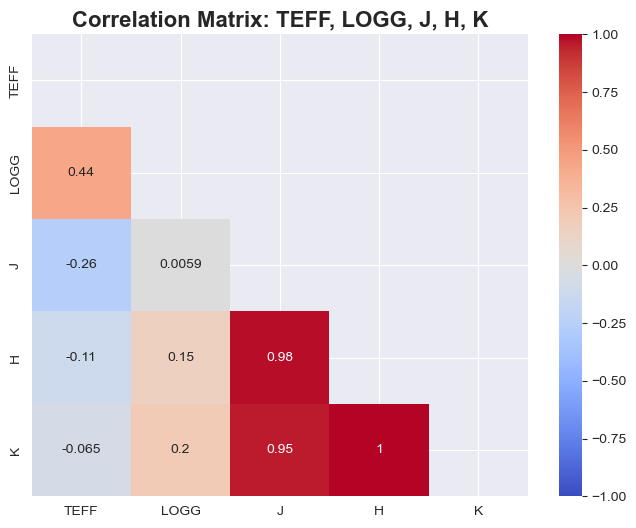

In [43]:
# Calculate correlation between TEFF LOGG, J H K

# Compute the correlation matrix
corr = sample[["TEFF", "LOGG", "J", "H", "K"]].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix: TEFF, LOGG, J, H, K", fontsize=16, fontweight='bold')
plt.show()


In [44]:
#créer un dataset qui contient les lignes sans valeurs manquantes
sample_0_miss = sample.dropna()

In [45]:

counter = Counter()
for flags in df['STARFLAGS']:
    flag_list = flags.split(',')
    counter.update(flag_list)

print("\nUnique starflag counts using Counter:")
print(counter)

counter_aspcap = Counter()
for flags in df['ASPCAPFLAGS']:
    flag_list = flags.split(',')
    counter_aspcap.update(flag_list)

print("\nUnique ASPCAPFLAG counts using Counter:")
print(counter_aspcap)



Unique starflag counts using Counter:
Counter({'': 356767, 'MTPFLUX_LT_75': 88900, 'BRIGHT_NEIGHBOR': 86182, 'PERSIST_LOW': 72452, 'PERSIST_HIGH': 48382, 'SUSPECT_BROAD_LINES': 29472, 'MTPFLUX_LT_50': 28867, 'SUSPECT_ROTATION': 27849, 'PERSIST_MED': 23038, 'LOW_SNR': 19449, 'MULTIPLE_SUSPECT': 9476, 'RV_FAIL': 3611, 'PERSIST_JUMP_NEG': 3372, 'RV_REJECT': 3185, 'PERSIST_JUMP_POS': 1559, 'VERY_BRIGHT_NEIGHBOR': 548, 'BAD_PIXELS': 33})

Unique ASPCAPFLAG counts using Counter:
Counter({'': 321928, 'VMICRO_WARN': 189612, 'VSINI_WARN': 151133, 'N_M_WARN': 142131, 'STAR_WARN': 90772, 'COLORTE_WARN': 75411, 'STAR_BAD': 35976, 'SN_BAD': 24449, 'TEFF_WARN': 23906, 'LOGG_WARN': 15489, 'NO_ASPCAP_RESULT': 11256, 'NO_GRID': 11256, 'VSINI_BAD': 10910, 'MISSING_APSTAR': 9546, 'MULTIPLE_SUSPECT': 9472, 'C_M_WARN': 7538, 'TEFF_BAD': 7484, 'LOGG_BAD': 7287, 'M_H_WARN': 5055, 'M_H_BAD': 4691, 'PROBLEM_TARGET': 3829, 'C_M_BAD': 3540, 'CHI2_BAD': 3540, 'VMICRO_BAD': 3380, 'ROTATION_WARN': 3362, 'ALPHA_M_W

In [46]:
# Define the flags that, if present, should cause the row to be dropped
to_delete_flags = ['LOW_SNR', 'STAR_BAD', "CHI2_BAD", "LOGG_BAD", "TEFF_BAD", "BRIGHT_NEIGHBOR", "MTPFLUX_LT_75", "PERSIST_LOW", "PERSIST_HIGH", "PERSIST_MED", "SUSPECT_ROTATION", "VMICRO_WARN", 'SUSPECT_BROAD_LINES', 'PERSIST_JUMP_NEG'
                   ]

to_delete_aspcap = ['VMICRO_WARN', 'N_M_WARN', 'VSINI_WARN', 'TEFF_WARN', 'STAR_WARN', 'C_M_WARN', 'COLORTE_WARN', 'LOGG_WARN', 'VMICRO_BAD', 'SN_BAD', 'ROTATION_WARN', 'C_M_BAD', 'VSINI_BAD', 'CHI2_WARN', 'ALPHA_M_WARN',
                    'VSINI_WARN', 'TEFF_WARN', 'N_M_WARN', 'STAR_WARN', 'C_M_WARN', 'COLORTE_WARN', 'LOGG_WARN', 'SN_BAD', 'VSINI_BAD', 'CHI2_WARN', 'ROTATION_WARN']

# Create a mask that is True for rows that do NOT contain any of the delete flags
mask = sample_0_miss['STARFLAGS'].apply(
    lambda x: not any(flag in to_delete_flags for flag in x.split(','))
)

# Filter the dataframe
df_filtered = sample_0_miss[mask]


In [47]:
mask_aspcap = df_filtered['ASPCAPFLAGS'].apply(
    lambda x: not any(flag in to_delete_aspcap for flag in x.split(','))
)

df_filtered = df_filtered[mask_aspcap]

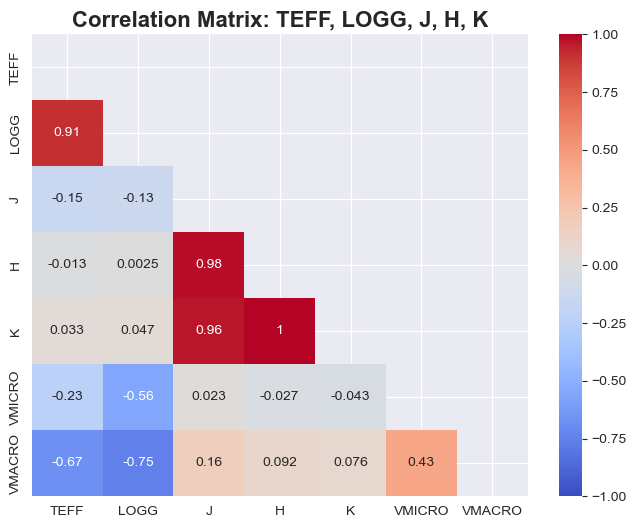

In [48]:
# Calculate correlation between TEFF LOGG, J H K

# Compute the correlation matrix
corr = df_filtered[["TEFF", "LOGG", "J", "H", "K", 'VMICRO', 'VMACRO']].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix: TEFF, LOGG, J, H, K", fontsize=16, fontweight='bold')
plt.show()


In [49]:
sample_0_miss.columns

Index(['apogee_id', 'J', 'H', 'K', 'LOGG', 'M_H', 'VMICRO', 'VMACRO', 'C_FE',
       'CI_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE', 'S_FE',
       'K_FE', 'CA_FE', 'TI_FE', 'V_FE', 'CR_FE', 'MN_FE', 'NI_FE', 'FE_H',
       'class_spectral', 'class_lum_logg', 'class_lum_jhk',
       'class_lum_bins_logg', 'class_lum_bins_jhk', 'STARFLAGS', 'ASPCAPFLAGS',
       'TEFF'],
      dtype='object')

In [50]:
# Remove unnecessary columns (STARFLAGS and ASPCAPFLAGS)
sample_0_miss = df_filtered.drop(columns=[
    'STARFLAGS', 'ASPCAPFLAGS', 'M_H', 'VMICRO', 'VMACRO', 'class_spectral',
    'class_lum_logg', 'class_lum_jhk', 'class_lum_bins_logg', 'class_lum_bins_jhk'
])

# drop duplicates apogee_id rows
print(sample_0_miss.shape)
sample_0_miss = sample_0_miss.drop_duplicates(subset='apogee_id')
print(sample_0_miss.shape)

# Define the ID column that should NEVER be scaled
id_column = ["apogee_id"]

# Define the target columns that should be excluded in some cases (TEFF, J, H, K, LOGG)
excluded_targets = ["TEFF", "J", "H", "K", "LOGG"]

# Identify non-numeric columns (these should not be scaled)
non_numeric_cols = sample_0_miss.select_dtypes(exclude=['number']).columns.tolist()

# Identify the columns to be scaled (all numeric columns except apogee_id)
all_numeric_columns = sample_0_miss.select_dtypes(include=['number']).columns.tolist()
columns_to_scale_all = [col for col in all_numeric_columns if col not in id_column]
columns_to_scale_partial = [col for col in all_numeric_columns if col not in id_column + excluded_targets]


(175770, 23)
(161406, 23)


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

SEED = 42  # Use this seed for reproducibility

# Splitting dataset into train/test sets
train_df, test_df = train_test_split(sample_0_miss, test_size=0.2, random_state=SEED)

# 1. Dataset with Standard Scaling applied to all numeric columns (except apogee_id)
scaler_standard_all = StandardScaler()
train_standard_all = train_df.copy()
test_standard_all = test_df.copy()

train_standard_all[columns_to_scale_all] = scaler_standard_all.fit_transform(train_standard_all[columns_to_scale_all])
test_standard_all[columns_to_scale_all] = scaler_standard_all.transform(test_standard_all[columns_to_scale_all])

train_standard_all.to_csv("../../data/train_resample_standard_all.csv", index=False)
test_standard_all.to_csv("../../data/test_resample_standard_all.csv", index=False)

print("✅ Export completed: Standard Scaling applied to all numeric columns.")

# 2. Dataset with Min-Max Scaling applied to all numeric columns (except apogee_id)
scaler_minmax_all = MinMaxScaler()
train_minmax_all = train_df.copy()
test_minmax_all = test_df.copy()

train_minmax_all[columns_to_scale_all] = scaler_minmax_all.fit_transform(train_minmax_all[columns_to_scale_all])
test_minmax_all[columns_to_scale_all] = scaler_minmax_all.transform(test_minmax_all[columns_to_scale_all])

train_minmax_all.to_csv("../../data/train_resample_minmax_all.csv", index=False)
test_minmax_all.to_csv("../../data/test_resample_minmax_all.csv", index=False)

print("✅ Export completed: Min-Max Scaling applied to all numeric columns.")

# 3. Dataset with Standard Scaling applied only to selected columns (excluding TEFF, J, H, K, LOGG)
scaler_standard_partial = StandardScaler()
train_standard_partial = train_df.copy()
test_standard_partial = test_df.copy()

train_standard_partial[columns_to_scale_partial] = scaler_standard_partial.fit_transform(train_standard_partial[columns_to_scale_partial])
test_standard_partial[columns_to_scale_partial] = scaler_standard_partial.transform(test_standard_partial[columns_to_scale_partial])

train_standard_partial.to_csv("../../data/train_resample_standard_excluded_targets.csv", index=False)
test_standard_partial.to_csv("../../data/test_resample_standard_excluded_targets.csv", index=False)

print("✅ Export completed: Standard Scaling applied excluding TEFF, J, H, K, LOGG.")

# 4. Dataset with Min-Max Scaling applied only to selected columns (excluding TEFF, J, H, K, LOGG)
scaler_minmax_partial = MinMaxScaler()
train_minmax_partial = train_df.copy()
test_minmax_partial = test_df.copy()

train_minmax_partial[columns_to_scale_partial] = scaler_minmax_partial.fit_transform(train_minmax_partial[columns_to_scale_partial])
test_minmax_partial[columns_to_scale_partial] = scaler_minmax_partial.transform(test_minmax_partial[columns_to_scale_partial])

train_minmax_partial.to_csv("../../data/train_resample_minmax_excluded_targets.csv", index=False)
test_minmax_partial.to_csv("../../data/test_resample_minmax_excluded_targets.csv", index=False)

print("✅ Export completed: Min-Max Scaling applied excluding TEFF, J, H, K, LOGG.")

✅ Export completed: Standard Scaling applied to all numeric columns.
✅ Export completed: Min-Max Scaling applied to all numeric columns.
✅ Export completed: Standard Scaling applied excluding TEFF, J, H, K, LOGG.
✅ Export completed: Min-Max Scaling applied excluding TEFF, J, H, K, LOGG.


Original DataFrame Shape: (161406, 23)
Train DataFrame Shape (Standard Scaling - All): (129124, 23)
Test DataFrame Shape (Standard Scaling - All): (32282, 23)


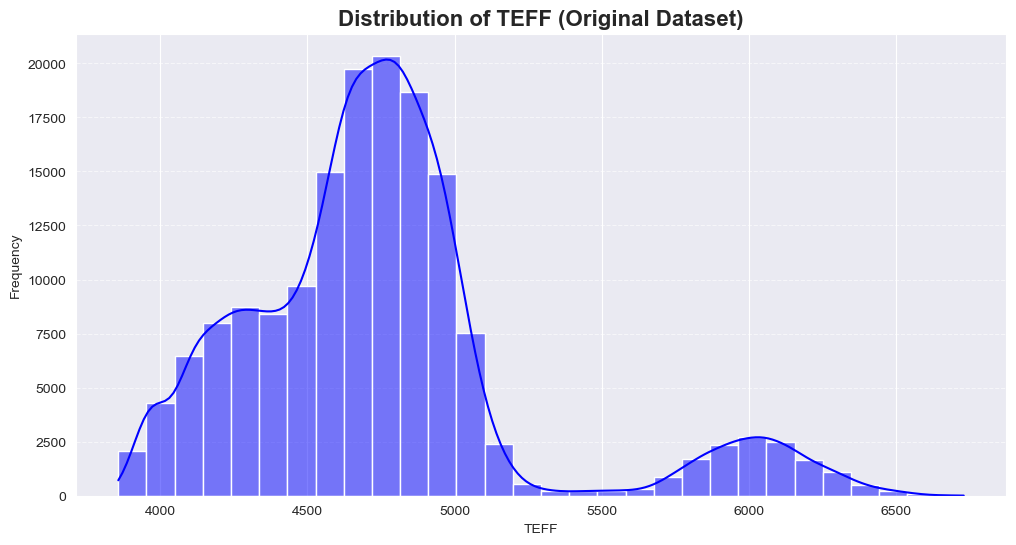

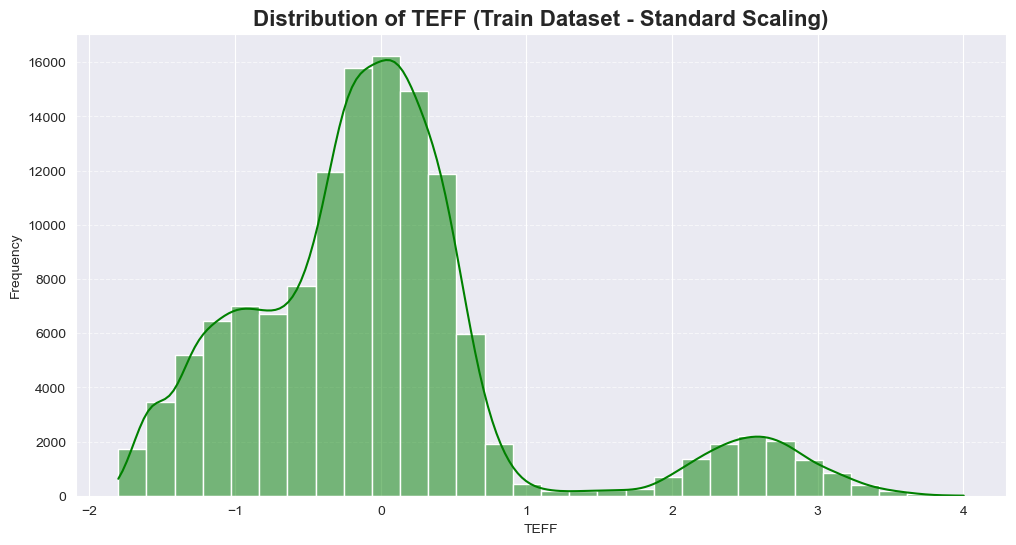

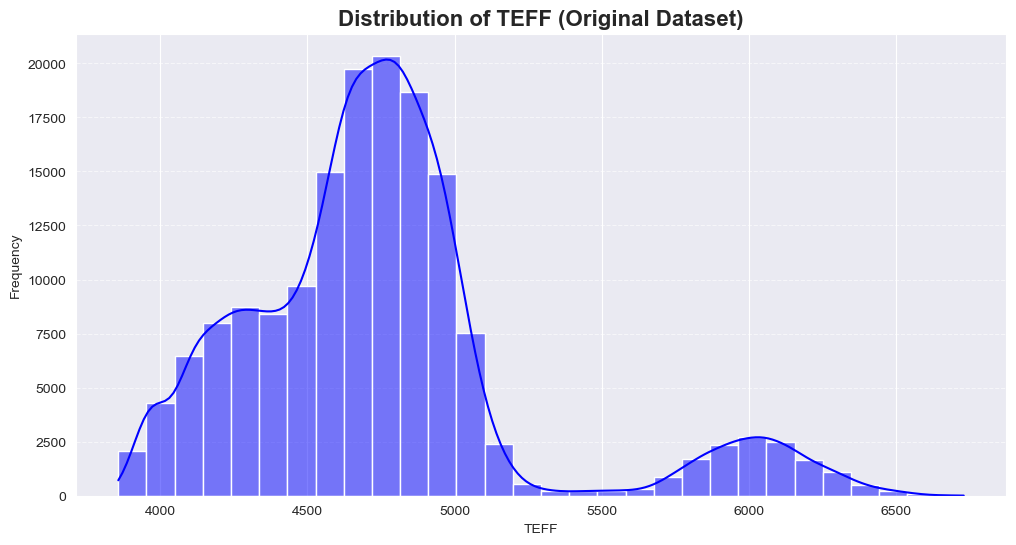

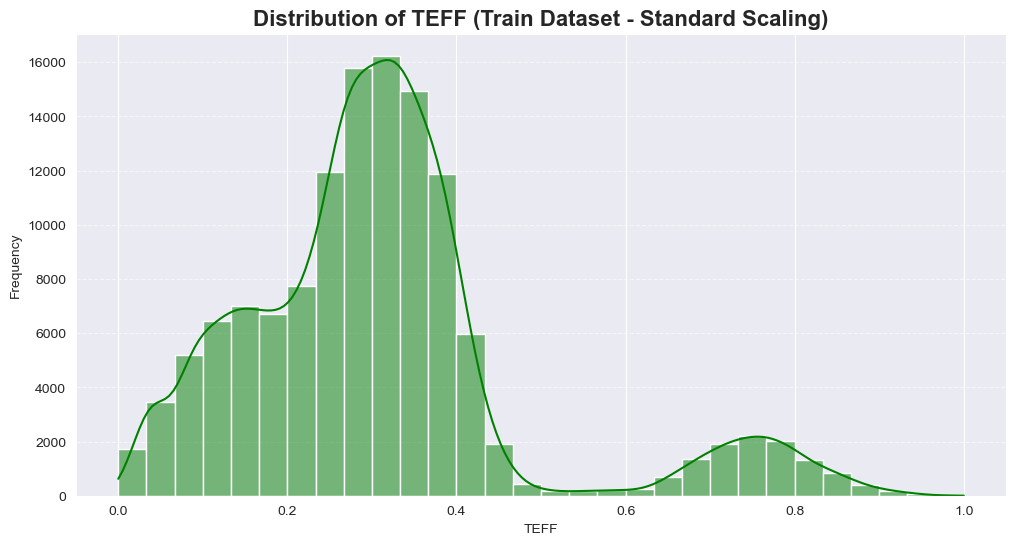

In [54]:
# display df shape

print("Original DataFrame Shape:", sample_0_miss.shape)
print("Train DataFrame Shape (Standard Scaling - All):", train_standard_all.shape)
print("Test DataFrame Shape (Standard Scaling - All):", test_standard_all.shape)

# plot the distribution of the target variable
plt.figure(figsize=(12, 6))
sns.histplot(sample_0_miss['TEFF'], kde=True, color='blue', bins=30)
plt.title("Distribution of TEFF (Original Dataset)", fontsize=16, fontweight='bold')
plt.xlabel("TEFF")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# plot the distribution of the target variable
plt.figure(figsize=(12, 6))
sns.histplot(train_standard_all['TEFF'], kde=True, color='green', bins=30)
plt.title("Distribution of TEFF (Train Dataset - Standard Scaling)", fontsize=16, fontweight='bold')
plt.xlabel("TEFF")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()










# plot the distribution of the target variable
plt.figure(figsize=(12, 6))
sns.histplot(sample_0_miss['TEFF'], kde=True, color='blue', bins=30)
plt.title("Distribution of TEFF (Original Dataset)", fontsize=16, fontweight='bold')
plt.xlabel("TEFF")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# plot the distribution of the target variable
plt.figure(figsize=(12, 6))
sns.histplot(train_minmax_all['TEFF'], kde=True, color='green', bins=30)
plt.title("Distribution of TEFF (Train Dataset - Standard Scaling)", fontsize=16, fontweight='bold')
plt.xlabel("TEFF")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


<Figure size 1500x600 with 0 Axes>

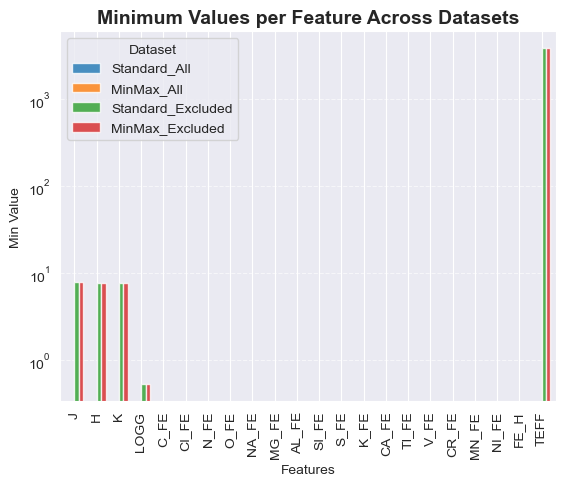

<Figure size 1500x600 with 0 Axes>

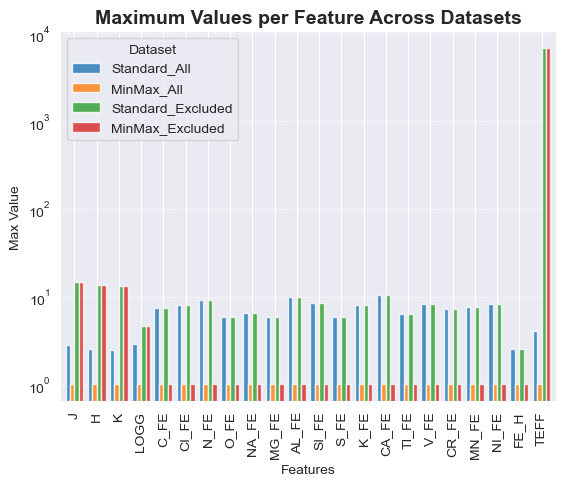

<Figure size 1500x600 with 0 Axes>

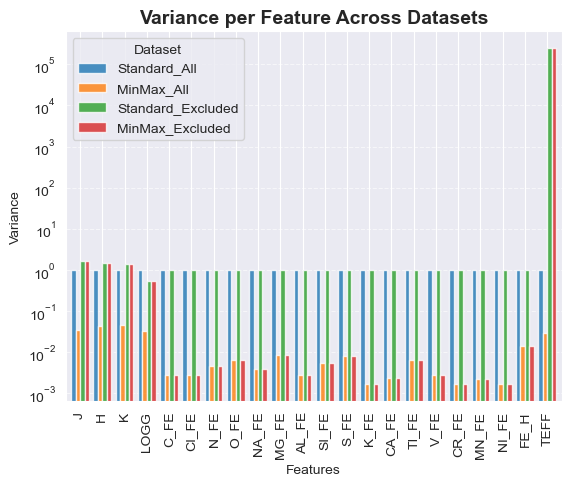

<Figure size 1500x600 with 0 Axes>

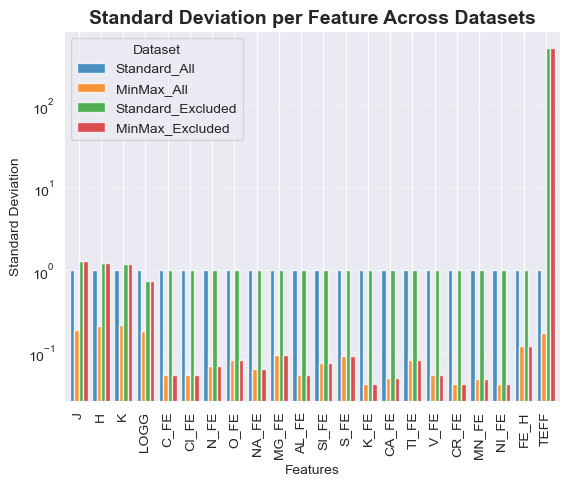

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
datasets = {
    "Standard_All": pd.read_csv("../../data/train_resample_standard_all.csv"),
    "MinMax_All": pd.read_csv("../../data/train_resample_minmax_all.csv"),
    "Standard_Excluded": pd.read_csv("../../data/train_resample_standard_excluded_targets.csv"),
    "MinMax_Excluded": pd.read_csv("../../data/train_resample_minmax_excluded_targets.csv")
}

# Identify numeric columns, excluding "apogee_id"
numeric_cols = [col for col in datasets["Standard_All"].select_dtypes(include=['number']).columns if col != "apogee_id"]

# Create a dictionary to store statistics for each dataset
stats = {stat: pd.DataFrame(index=numeric_cols) for stat in ["Min", "Max", "Variance", "Std"]}

# Compute statistics for each dataset and store them in the dictionary
for name, df in datasets.items():
    stats["Min"][name] = df[numeric_cols].min()
    stats["Max"][name] = df[numeric_cols].max()
    stats["Variance"][name] = df[numeric_cols].var()
    stats["Std"][name] = df[numeric_cols].std()

# Define a function to plot statistics
def plot_stat(df, title, ylabel):
    plt.figure(figsize=(15, 6))
    df.plot(kind='bar', width=0.8, alpha=0.8)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Features")
    plt.ylabel(ylabel)
    plt.semilogy()
    plt.xticks(rotation=90)
    plt.legend(title="Dataset")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

# Plot Min, Max, Variance, and Standard Deviation
plot_stat(stats["Min"], "Minimum Values per Feature Across Datasets", "Min Value")
plot_stat(stats["Max"], "Maximum Values per Feature Across Datasets", "Max Value")
plot_stat(stats["Variance"], "Variance per Feature Across Datasets", "Variance")
plot_stat(stats["Std"], "Standard Deviation per Feature Across Datasets", "Standard Deviation")
